# 0.0. IMPORTS

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as m
import seaborn as sns
import scipy
import warnings
import sweetviz as sv
from scipy.stats import boxcox
#Imports para analise e modelagem de series temporais
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
warnings.filterwarnings( 'ignore' )

/home/felipe/anaconda3/envs/ts_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/felipe/anaconda3/envs/ts_env/lib/python3.10/site-packages/sweetviz/graph.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


## 0.1. Helper Functions

## 0.2. Loading data

In [2]:
data = pd.read_csv('../datasets/Foodshop.csv')

# 1.0. (STEP 1) DATA DESCRIPTION

In [3]:
df1 = data.copy()

## 1.1. Rename Columns

In [4]:
#No need to rename columns
df1.columns

Index(['date', 'consumption_mwh_day', 'temp_mean_c', 'is_holiday'], dtype='object')

## 1.2. Data Dimensions

In [5]:
print('Number of Rows: {}'.format(df1.shape[0]))
print('Number of Cols: {}'.format(df1.shape[1]))

Number of Rows: 9549
Number of Cols: 4


## 1.3. Data Types

In [6]:
df1.dtypes

date                    object
consumption_mwh_day    float64
temp_mean_c            float64
is_holiday               int64
dtype: object

In [7]:
df1['date'] = pd.to_datetime(df1['date'])

## 1.4. Check NA

In [8]:
df1.isna().sum()

date                     0
consumption_mwh_day      4
temp_mean_c            113
is_holiday               0
dtype: int64

## 1.5. Fillout NA

In [9]:
# Adding info about year and month to the dataset
df1['year'] = df1['date'].dt.year
df1['month'] = df1['date'].dt.month

In [10]:
# consumption_mwh_day  NAs, will be filled with the monthly mean of the respective year
df1_temp = df1[df1['consumption_mwh_day'].isna()== True]
df1_temp

,date,consumption_mwh_day,temp_mean_c,is_holiday,year,month
5083,2013-12-01,NaN,21.0,0,2013,12
5145,2014-02-01,NaN,27.2,0,2014,2
5577,2015-04-09,NaN,19.3,0,2015,4
9548,2026-02-21,NaN,NaN,0,2026,2


In [11]:
df1['consumption_mwh_day']= df1['consumption_mwh_day'].fillna(df1.groupby(['year','month'])['consumption_mwh_day'].transform('mean'))

In [12]:
df1.iloc[4780]

date                   2013-02-01 00:00:00
consumption_mwh_day             444.393631
temp_mean_c                           23.2
is_holiday                               0
year                                  2013
month                                    2
Name: 4780, dtype: object

In [13]:
df1.iloc[5212]

date                   2014-04-09 00:00:00
consumption_mwh_day             479.517112
temp_mean_c                           24.8
is_holiday                               0
year                                  2014
month                                    4
Name: 5212, dtype: object

In [14]:
# temp_mean_c  NAs, will be filled with the monthly mean of the respective year
df1_temp = df1[df1['temp_mean_c'].isna()== True]
df1_temp.head()

,date,consumption_mwh_day,temp_mean_c,is_holiday,year,month
51,2000-02-21,303.68105,NaN,0,2000,2
58,2000-02-28,324.46105,NaN,0,2000,2
96,2000-04-06,319.22475,NaN,0,2000,4
103,2000-04-13,333.03655,NaN,0,2000,4
104,2000-04-14,334.47080,NaN,0,2000,4


In [15]:

df1['temp_mean_c'] = df1['temp_mean_c'].fillna(df1.groupby(['year','month'])['temp_mean_c'].transform('mean'))

In [16]:
df1.iloc[51]

date                   2000-02-21 00:00:00
consumption_mwh_day              303.68105
temp_mean_c                           22.6
is_holiday                               0
year                                  2000
month                                    2
Name: 51, dtype: object

In [17]:
df1.iloc[96]

date                   2000-04-06 00:00:00
consumption_mwh_day              319.22475
temp_mean_c                      21.166667
is_holiday                               0
year                                  2000
month                                    4
Name: 96, dtype: object

In [18]:
# CHecking if all NAs were filled out
df1.isna().sum()

date                   0
consumption_mwh_day    0
temp_mean_c            0
is_holiday             0
year                   0
month                  0
dtype: int64

## 1.6. Change Types

In [19]:
df1.dtypes

date                   datetime64[ns]
consumption_mwh_day           float64
temp_mean_c                   float64
is_holiday                      int64
year                            int32
month                           int32
dtype: object

In [20]:
df1['is_holiday'] = df1['is_holiday'].astype('bool')

## 1.7. Descriptive Statistical

### 1.7.1 Numerical Attributes

In [21]:
num_attributes = df1.select_dtypes(include=['float64'])

In [22]:
#Central Tendency - mean, median

ct1 = pd.DataFrame(num_attributes.apply(np.mean)).T
ct2 = pd.DataFrame(num_attributes.apply(np.median)).T

# Dispersion - std, min, max, range, skew, kurtosis
d1 = pd.DataFrame(num_attributes.apply(np.std)).T
d2 = pd.DataFrame(num_attributes.apply(min)).T
d3 = pd.DataFrame(num_attributes.apply(max)).T
d4 = pd.DataFrame(num_attributes.apply(lambda x: x.max() - x.min())).T
d5 = pd.DataFrame(num_attributes.apply(lambda x: x.skew())).T
d6 = pd.DataFrame(num_attributes.apply(lambda x: x.kurtosis())).T

#concatenate
m = pd.concat([d2,d3,d4,ct1,ct2,d1,d5,d6]).T.reset_index()
m.columns = ['attribute','min','max','range','mean','median','std','skew','kurtosis']
m

,attribute,min,max,range,mean,median,std,skew,kurtosis
0,consumption_mwh_day,190.54063,667.01876,476.47813,406.760037,406.666325,78.411485,0.184981,-0.247815
1,temp_mean_c,7.10000,29.50000,22.40000,20.248256,20.500000,3.422695,-0.304939,-0.214175


In [23]:
#    - Skewness: Measures the asymmetry. 
#      (Skew > 0: Right tail; Skew < 0: Left tail; Skew ~ 0: Symmetric).
#    - Kurtosis: Measures the "peakedness" and presence of outliers.
#      (Negative values indicate a flatter distribution with fewer extremes).

In [24]:
'''
Consumption: Shows low skewness (0.19) and negative kurtosis (-0.31), 
suggesting a well-behaved, slightly flat distribution without extreme outliers.

Temperature: The negative skewness (-0.30) indicates a slight concentration of higher temperatures 
with a tail extending toward the colder days.

'''



'\nConsumption: Shows low skewness (0.19) and negative kurtosis (-0.31), \nsuggesting a well-behaved, slightly flat distribution without extreme outliers.\n\nTemperature: The negative skewness (-0.30) indicates a slight concentration of higher temperatures \nwith a tail extending toward the colder days.\n\n'

In [25]:
# code to avoid the warning of sweetviz when analyzing the dataset
if not hasattr(np, 'VisibleDeprecationWarning'):
    np.VisibleDeprecationWarning = UserWarning
#description with sweetviz
eda=sv.analyze(df1)
eda.show_html()

Done! Use 'show' commands to display/save.   |██████████| [100%]   00:00 -> (00:00 left)


Report SWEETVIZ_REPORT.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


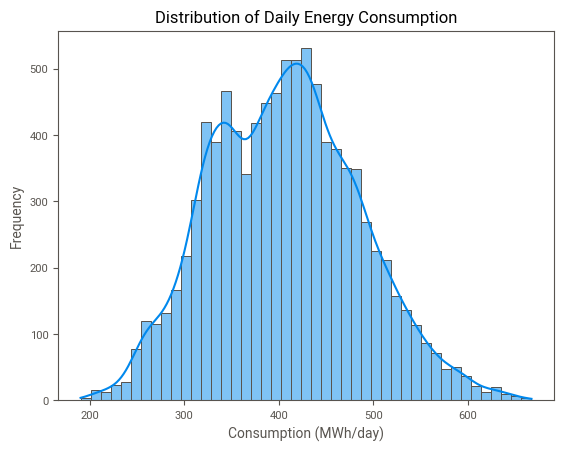

In [26]:
sns.histplot(df1['consumption_mwh_day'], kde=True)
plt.title('Distribution of Daily Energy Consumption')
plt.xlabel('Consumption (MWh/day)')
plt.ylabel('Frequency')
plt.show()

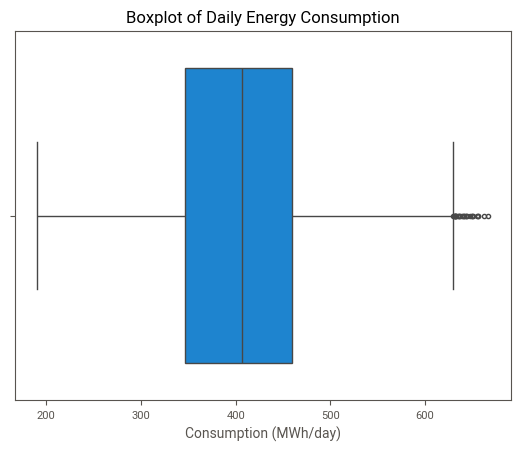

In [27]:
sns.boxplot(x=df1['consumption_mwh_day'])
plt.title('Boxplot of Daily Energy Consumption')
plt.xlabel('Consumption (MWh/day)')
plt.show()

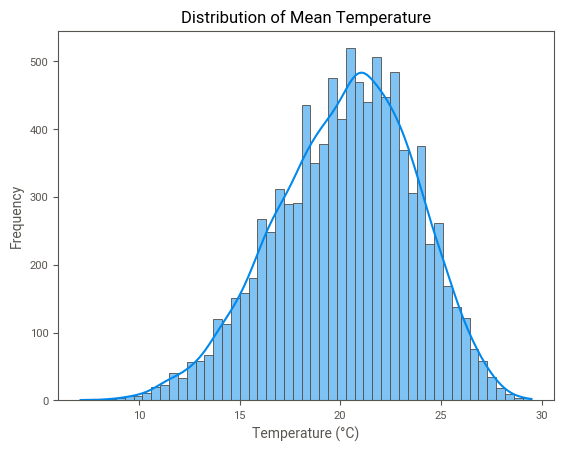

In [28]:
sns.histplot(df1['temp_mean_c'], kde=True)
plt.title('Distribution of Mean Temperature')
plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')
plt.show()

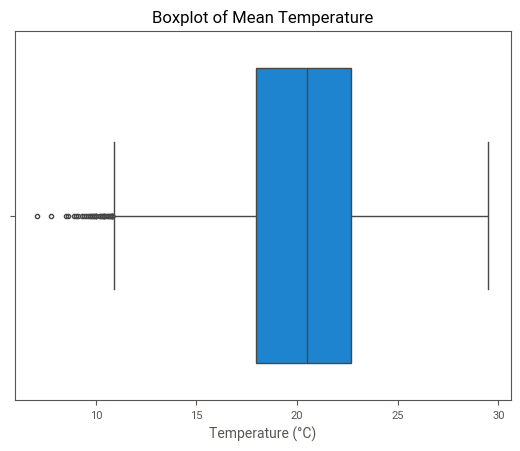

In [29]:
sns.boxplot(x=df1['temp_mean_c'])   
plt.title('Boxplot of Mean Temperature')
plt.xlabel('Temperature (°C)')
plt.show()  

# 2.0. (STEP 2) EXPLORATORY DATA ANALYSIS - EDA


In [30]:
df2 = df1.copy()

### H1. Energy consumption is expected to be higher during holidays. (Ans.: False)

In [31]:

df2_temp =df2.groupby('is_holiday')['consumption_mwh_day'].mean().reset_index()
df2_temp


,is_holiday,consumption_mwh_day
0,False,408.457566
1,True,367.000515


### H2. Energy consumption during the summer period (December-March) is expected to be higher than during the winter period (June-September). (Ans.: True)

In [32]:
df2_temp = df2.groupby('month')['consumption_mwh_day'].sum().reset_index()
df2_temp

,month,consumption_mwh_day
0,1,352335.169001
1,2,327667.844208
2,3,345684.544266
3,4,318149.121915
4,5,315150.889191
5,6,298554.283268
6,7,307758.982824
7,8,316995.414458
8,9,317273.705306
9,10,332481.617972


In [33]:
df2_temp_summer = df2_temp[df2_temp['month'].isin([12, 1, 2, 3])]
df2_temp_winter = df2_temp[df2_temp['month'].isin([6, 7, 8, 9])]
print('Summer average consumption: {} MWh'.format(df2_temp_summer['consumption_mwh_day'].sum()))
print('Winter average consumption: {} MWh'.format(df2_temp_winter['consumption_mwh_day'].sum()))

Summer average consumption: 1357980.9878315204 MWh
Winter average consumption: 1240582.3858572848 MWh


### H3. The average consumption of the last 10 years is higher than the sum of all previous years. (Ans.: True) 

In [34]:
df2['year'].unique()

array([2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010,
       2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021,
       2022, 2023, 2024, 2025, 2026], dtype=int32)

In [35]:
df2_temp = df2.groupby('year')['consumption_mwh_day'].mean().reset_index()
df2_temp

,year,consumption_mwh_day
0,2000,308.708173
1,2001,279.160443
2,2002,300.078914
3,2003,313.687892
4,2004,326.974273
5,2005,340.277962
6,2006,352.229837
7,2007,370.100835
8,2008,377.664774
9,2009,372.983131


In [36]:
df2_temp_last_10 = df2_temp[df2_temp['year'].between(2016,2026)]
df2_temp_before_last_10 = df2_temp[df2_temp['year'].between(2000,2015)]


In [37]:
print('Average consumption in the last 10 years: {} MWh'.format(df2_temp_last_10['consumption_mwh_day'].mean()))
print('Average consumption before the last 10 years: {} MWh'.format(df2_temp_before_last_10['consumption_mwh_day'].mean()))

Average consumption in the last 10 years: 477.7458592418489 MWh
Average consumption before the last 10 years: 366.3076404696415 MWh


## Time Series EDA

In [38]:
# Formatacao para graficos e tabelas
plt.style.use('ggplot')
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

In [39]:
#Formatando os labels dos graficos
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
#m.rcParams['legend.fontsize'] = 12
#m.rcParams['figure.titlesize'] = 16 
plt.rcParams['text.color'] = 'k'

In [40]:
energy_consumption_serie = df2.set_index('date')[['consumption_mwh_day']]

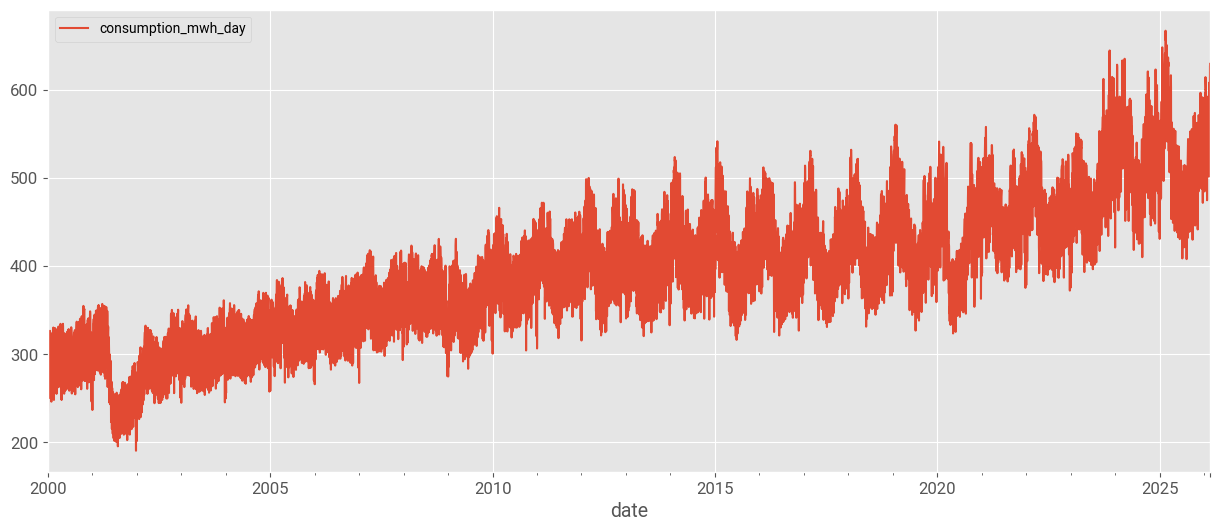

In [41]:
#Plot da Serie Temporal 
energy_consumption_serie.plot(figsize=(15,6))
plt.show()

### 1. 2001 Energy Rationing Crisis ("The Blackout Crisis")
A sharp, abrupt drop is visible at the beginning of the series (2001). This corresponds 
to the **mandatory energy rationing** imposed by the Brazilian government between June 2001 
and February 2002.

* **Cause:** Critical reservoir levels in the Southeast/Midwest regions due to 
severe droughts and a lack of infrastructure investment.
* **Impact:** A government-mandated **20% reduction target** forced a structural 
shift in consumption habits. Note that the series takes nearly two years to return 
to pre-crisis levels.

### 2. Post-2020 Dynamics: Pandemic Impact and Recent Uptrend
From 2020 onwards, the series enters a phase of higher volatility and a steeper 
positive slope:

* **COVID-19 Shock (2020):** There is a visible "dip" corresponding to the initial 
lockdowns, where industrial and commercial demand fell sharply, partially offset 
by a surge in residential load (Remote Work).
* **The Post-2021 Growth:** The sharp upward trend seen from 2021 to 2025 reflects 
economic recovery combined with **extreme heatwaves**. Increased temperatures in 
the Southeast and Midwest have driven record-breaking peaks in cooling demand 
(air conditioning), pushing the overall baseline of the series higher.

In [42]:
energy_consumption_serie.reset_index()

,date,consumption_mwh_day
0,2000-01-01,228.551950
1,2000-01-02,232.776300
2,2000-01-03,276.740950
3,2000-01-04,290.738900
4,2000-01-05,297.695250
...,...,...
9544,2026-02-17,586.724395
9545,2026-02-18,626.864414
9546,2026-02-19,628.908878
9547,2026-02-20,629.855458


Text(0.5, 1.0, 'Boxplot of Energy consumption per year')

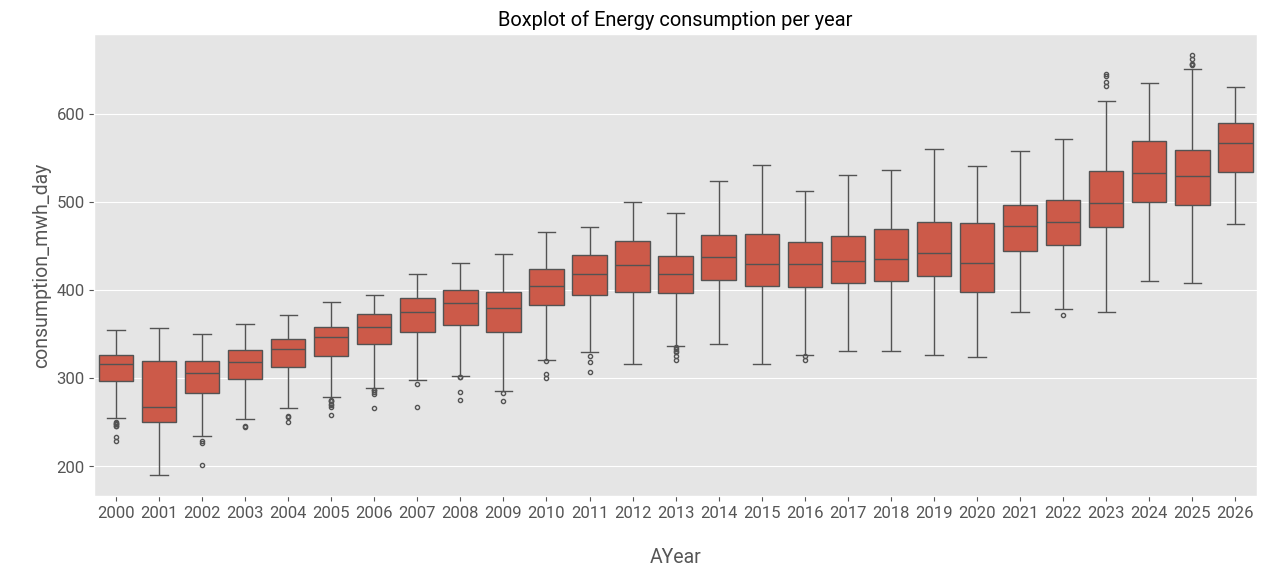

In [43]:
# Define a area de plotagem para os subplots
fig, ax = plt.subplots(1, figsize=(15,6))

#Define as variaveis
indice_ano = energy_consumption_serie.index.year
valor = energy_consumption_serie.values.flatten() # Pega os valores da série e transforma em array 1D

#Cria um boxplot  para cada ano
sns.boxplot(x=indice_ano, y=valor, ax = ax)
plt.xlabel('\nAYear')
plt.ylabel('\nconsumption_mwh_day')
plt.title('Boxplot of Energy consumption per year')

### Summary of Annual Distribution Insights
Based on the yearly boxplot analysis, we can conclude the following structural patterns:

1. **Persistent Upward Trend:** The steady increase in the median throughout the years indicates a clear ascending trend in energy consumption.
2. **Stable Structural Growth:** There is a constant increase in the values surrounding the median over time. This suggests that the entire energy demand profile is shifting upward consistently, maintaining a stable distribution while reaching higher baselines.
3. **Extreme Demand Peaks:** The presence of upper outliers in the 2023 and 2025 boxplots indicates aggressive consumption peaks. These spikes are strong indicators of extreme weather events (heatwaves) that drive cooling demand significantly beyond the typical statistical range.

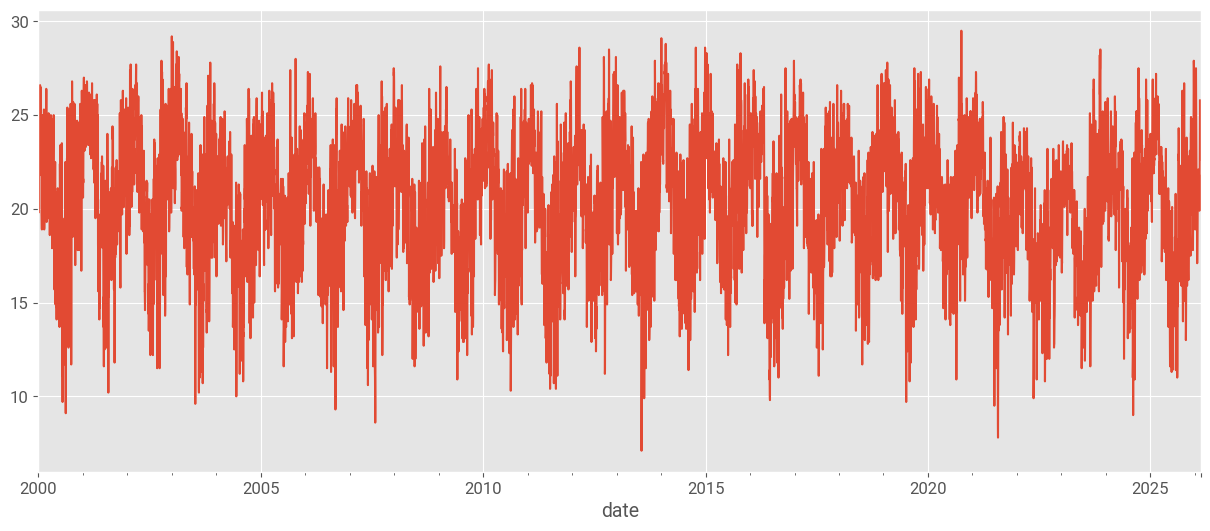

In [44]:
temperature_serie = df2.set_index('date')['temp_mean_c']
temperature_serie.plot(figsize=(15,6))
plt.show()

### 
The temperature series provides the climatic context necessary to understand energy 
demand fluctuations. We can see that in summer time when the temperature is higher the consumption is also higher

Pearson Correlation: 0.18


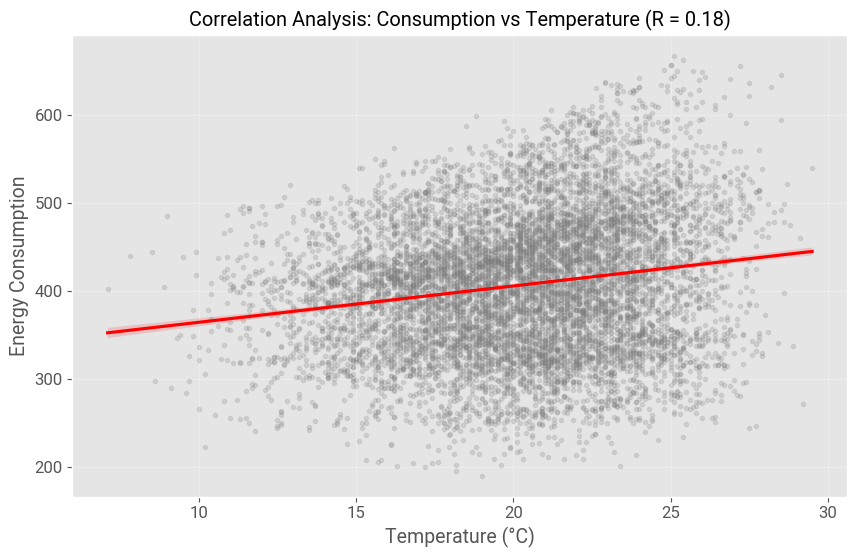

In [45]:
correlation = df2['consumption_mwh_day'].corr(df2['temp_mean_c'])
print(f"Pearson Correlation: {correlation:.2f}")

# Visualizando a relação com um Scatter Plot e Regressão Linear
plt.figure(figsize=(10, 6))
sns.regplot(data=df2, x='temp_mean_c', y='consumption_mwh_day', 
            scatter_kws={'alpha':0.2, 'color':'gray'}, 
            line_kws={'color':'red'})

plt.title(f'Correlation Analysis: Consumption vs Temperature (R = {correlation:.2f})')
plt.xlabel('Temperature (°C)')
plt.ylabel('Energy Consumption')
plt.grid(True, alpha=0.3)
plt.show()

### 
The scatter plot reveals a **weak positive correlation** (0.18) between daily temperature 
and energy consumption. While a positive trend is visible (red line), the low R-value 
suggests that temperature alone does not explain the bulk of consumption variance. In other hand we can see the higher values of energy consumption (>500) are concentrated in region with high temperature >20°C.

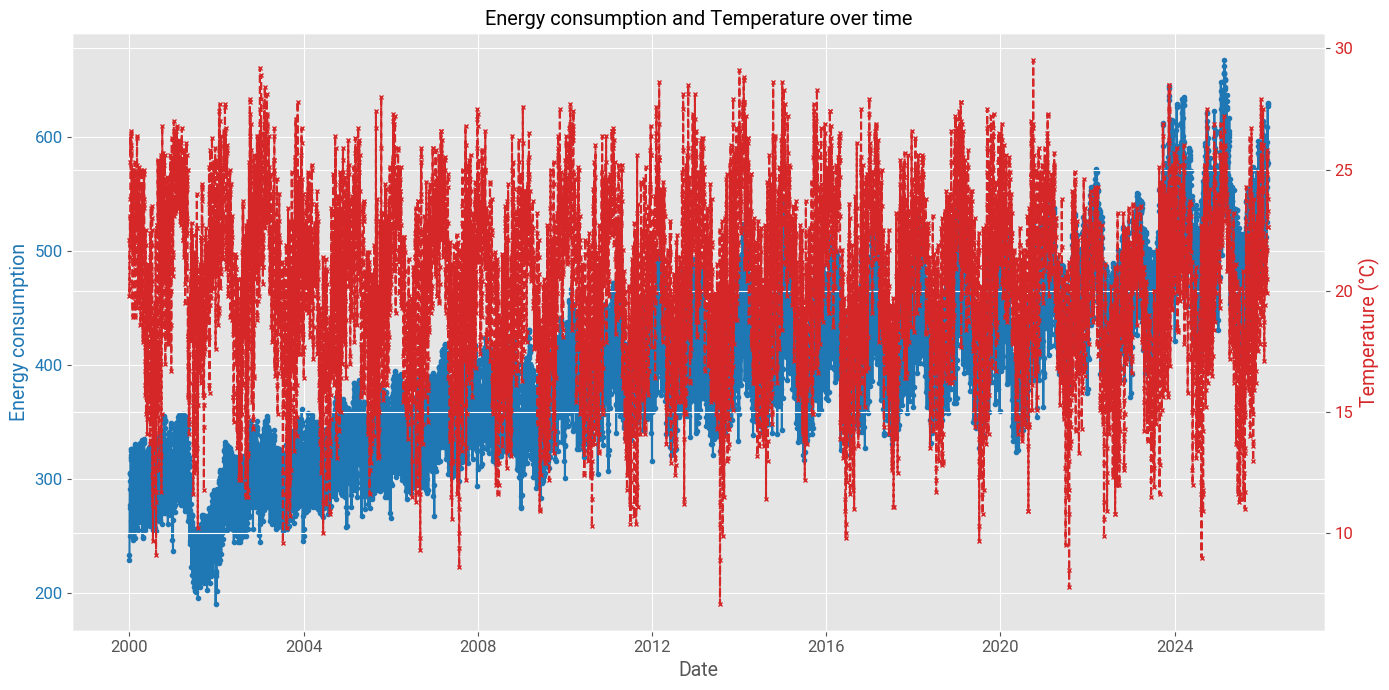

In [52]:
# Cria uma figura e eixos para os gráficos
fig, ax1 = plt.subplots(figsize=(14, 7))

# Plot do Consumo de Energia
ax1.plot(df2['date'], df2['consumption_mwh_day'], color='tab:blue', marker='o', linestyle='-', label='Energy consumption')
ax1.set_xlabel('Date')
ax1.set_ylabel('Energy consumption', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True)

# Cria um segundo eixo y para a Temperatura
ax2 = ax1.twinx() # Cria um segundo eixo Y (direito) compartilhando o eixo X, para plotar a Temperatura que tem uma escala diferente.
ax2.plot(df2['date'], df2['temp_mean_c'], color='tab:red', marker='x', linestyle='--', label='Temperature')
ax2.set_ylabel('Temperature (°C)', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

# Adiciona título e legendas
plt.title('Energy consumption and Temperature over time')
fig.tight_layout()  # Para ajustar bem o layout
plt.show()

In [ ]:
#For past 10 years only
df2_temp_plot = df2[df2['date'].between('2016-01-01', '2026-12-31')].copy()

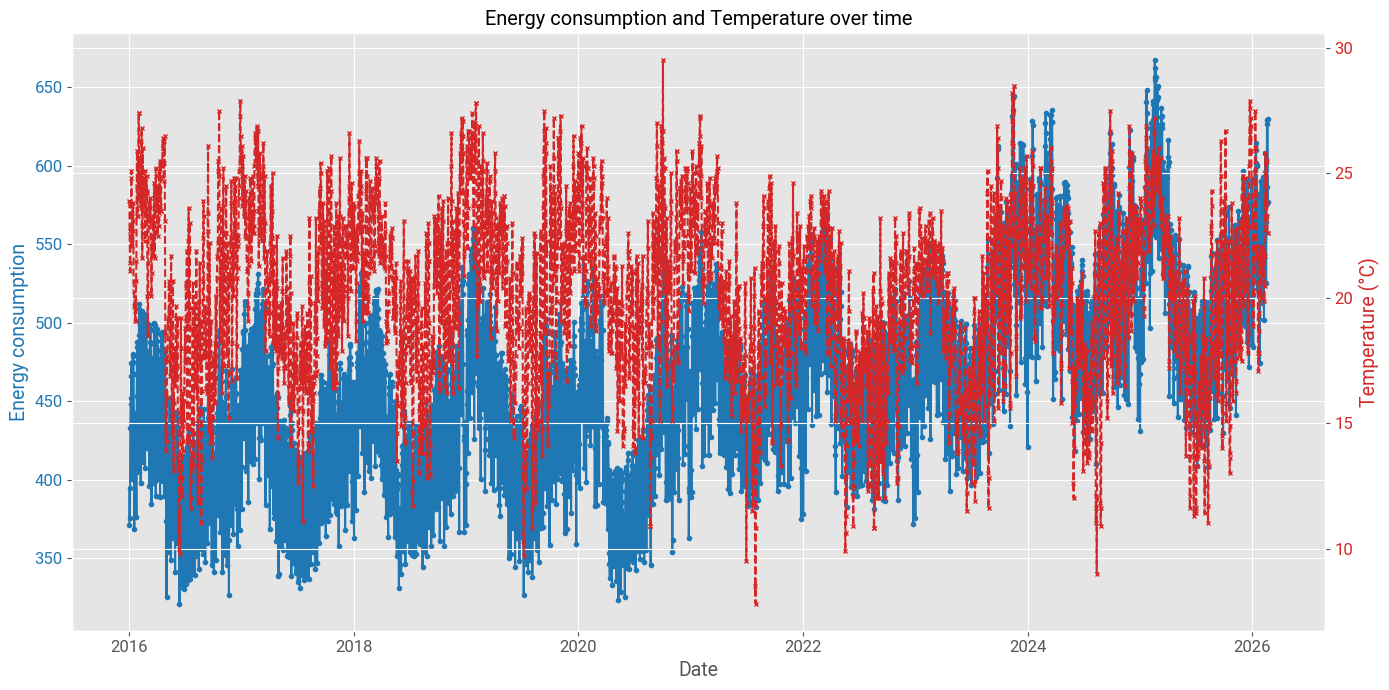

In [53]:
# Cria uma figura e eixos para os gráficos
fig, ax1 = plt.subplots(figsize=(14, 7))

# Plot do Consumo de Energia
ax1.plot(df2_temp_plot['date'], df2_temp_plot['consumption_mwh_day'], color='tab:blue', marker='o', linestyle='-', label='Energy consumption')
ax1.set_xlabel('Date')
ax1.set_ylabel('Energy consumption', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True)

# Cria um segundo eixo y para a Temperatura
ax2 = ax1.twinx() # Cria um segundo eixo Y (direito) compartilhando o eixo X, para plotar a Temperatura que tem uma escala diferente.
ax2.plot(df2_temp_plot['date'], df2_temp_plot['temp_mean_c'], color='tab:red', marker='x', linestyle='--', label='Temperature')
ax2.set_ylabel('Temperature (°C)', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

# Adiciona título e legendas
plt.title('Energy consumption and Temperature over time')
fig.tight_layout()  # Para ajustar bem o layout
plt.show()

### Historical data (2016-2026) showing energy consumption following temperature trends.Temperature peaks drive higher energy consumption.